I USED REDBULL FOR THE THIRD CLASS I WAS CURIOUS HOW CLOSE IT WOULD THINK COCA COLA WOULD
BE TO IT ALSO USED A NINTENDO PRO CONTROLLER TO TRAIN THAT AND USED A RED HAMMER FOR THE THIRD. 

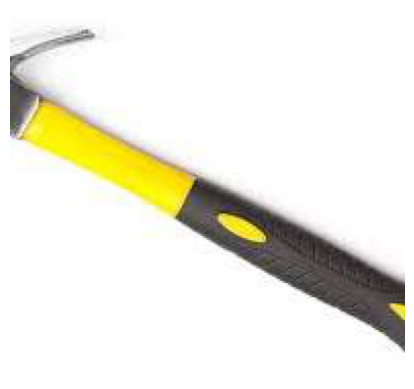

1/1 [==============================] - 1s 648ms/step
Image: Hammer.jpg
Class: 0 Hammer
Confidence Score: 0.9999186



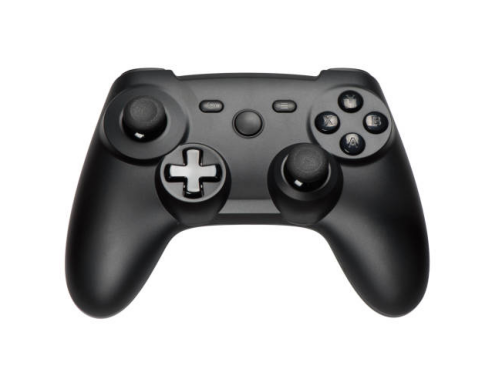

1/1 [==============================] - 0s 27ms/step
Image: Controller.jpg
Class: 0 Hammer
Confidence Score: 0.8330977



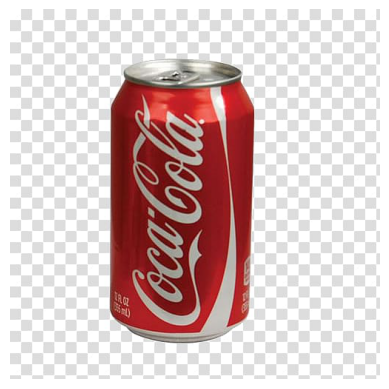

1/1 [==============================] - 0s 25ms/step
Image: Soda.jpg
Class: 0 Hammer
Confidence Score: 0.5824316



In [6]:
from keras.models import load_model
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

# Disable scientific notation for clarity
np.set_printoptions(suppress=True)

# Load the model
model = load_model("keras_Model.h5", compile=False)

# Load the labels
class_names = open("labels.txt", "r").readlines()

# List of image paths
image_paths = ["Hammer.jpg", "Controller.jpg", "Soda.jpg"]

# Function to preprocess image
def preprocess_image(image_path):
    # Open the image
    image = Image.open(image_path)
    
    # Resize and crop the image
    size = (224, 224)
    image = ImageOps.fit(image, size, Image.Resampling.LANCZOS)

    # Convert image to numpy array and normalize
    image_array = np.asarray(image)
    normalized_image_array = (image_array.astype(np.float32) / 127.5) - 1
    
    return normalized_image_array

# Make predictions for each image
for image_path in image_paths:
    # Preprocess image
    normalized_image_array = preprocess_image(image_path)
    
    # Display the image
    plt.imshow(Image.open(image_path))
    plt.axis('off')
    plt.show()
    
    # Create data array
    data = np.expand_dims(normalized_image_array, axis=0)
    
    # Predict the model
    prediction = model.predict(data)
    index = np.argmax(prediction)
    class_name = class_names[index]
    confidence_score = prediction[0][index]
    
    # Print prediction and confidence score
    print("Image:", image_path)
    print("Class:", class_name.strip())
    print("Confidence Score:", confidence_score)
    print()
